# Salary regression
**Group 4 | BU MET AD688 | Data Analyst careers in NAICS 523**

**Question:** Do experience, location, remote status and skill requirements help explain advertised salary midpoints?

We compare multiple linear regression and Random Forest with a simple average-salary benchmark. The main results are RMSE, MAE and R². Tables stay in this notebook; only three figures needed by the report are saved.


## 1. Load the data


In [1]:
from pathlib import Path
import json
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display, Markdown

# Run this notebook from the project folder.
PROJECT = Path.cwd()
if not (PROJECT / "data/career_market_panel.csv").exists():
    PROJECT = PROJECT.parent

DATA_FILE = PROJECT / "data/career_market_panel.csv"
FIGURES = PROJECT / "figures"
RESULTS = PROJECT / "output/regression"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 180})
print("Data shape:", df.shape)
print("Posting dates:", df["POSTED"].min(), "to", df["POSTED"].max())
df.head(3)


Data shape: (140, 42)
Posting dates: 2024-05-02 to 2024-09-30


,ID,LAST_UPDATED_DATE,POSTED,EXPIRED,TITLE_RAW,BODY,COMPANY_NAME,EDUCATION_LEVELS_NAME,MIN_YEARS_EXPERIENCE,MAX_YEARS_EXPERIENCE,...,ONET,ONET_NAME,SOC_2021_5,SOC_2021_5_NAME,remote_status,city_clean,state_clean,salary_midpoint,industry_scope,career_scope
0,0157c403b9d6c4de322cf7e311ba4f1fb119b802,2024-10-09,2024-07-09,2024-07-24,Data Analyst II,Data Analyst II Risk Solutions - 5.0 Alpharett...,Risk Solutions,"[\n ""Bachelor's degree""\n]",NaN,NaN,...,15-2051.01,Business Intelligence Analysts,15-2051,Data Scientists,Unknown,"Alpharetta, GA",Georgia,NaN,NAICS 523,Core Data Analyst
1,6273f8cf57a3df15b8a5d04b3a34704259112e43,2024-08-12,2024-06-11,2024-07-04,Product Data Analyst,Alternate Locations: Work from Home; Fort Wayn...,Lincoln Financial Group,"[\n ""Bachelor's degree""\n]",5.0,NaN,...,15-2051.01,Business Intelligence Analysts,15-2051,Data Scientists,Remote,"Helena, MT",Montana,93850.0,NAICS 523,Core Data Analyst
2,acf1a5b458391432d29a4a6b46dac9fec0f0597d,2024-08-12,2024-06-11,2024-07-04,Product Data Analyst,Alternate Locations: Work from Home; Fort Wayn...,Lincoln Financial Group,"[\n ""Bachelor's degree""\n]",5.0,NaN,...,15-2051.01,Business Intelligence Analysts,15-2051,Data Scientists,Remote,"Jackson, MS",Mississippi,93850.0,NAICS 523,Core Data Analyst


## 2. Prepare the model fields
- Keep missing salary as missing, rather than zero.
- Fill missing experience from the training data during validation.
- Keep unknown work arrangements as `Unknown`.
- Skill lists are JSON text stored inside CSV cells. Read those lists and create 0/1 indicators: 1 means the posting mentions the skill.


In [2]:
# Convert numeric fields. Missing experience stays missing for now.
number_cols = ["salary_midpoint", "SALARY_FROM", "SALARY_TO", "MIN_YEARS_EXPERIENCE"]
for col in number_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.loc[df["MIN_YEARS_EXPERIENCE"] < 0, "MIN_YEARS_EXPERIENCE"] = np.nan

# Use the cleaned location and remote fields instead of their raw duplicates.
for col in ["remote_status", "city_clean", "state_clean"]:
    df[col] = df[col].fillna("Unknown").str.strip().replace("", "Unknown")
# Original pay period is metadata; the salary amounts were already annualized.
df["pay_period"] = df["ORIGINAL_PAY_PERIOD"].fillna("Unknown").str.lower().str.strip()

print("Duplicate IDs:", df["ID"].duplicated().sum())
df = df.drop_duplicates("ID").copy()
print("Missing salary:", df["salary_midpoint"].isna().sum())
print("Missing minimum experience:", df["MIN_YEARS_EXPERIENCE"].isna().sum())


Duplicate IDs: 0
Missing salary: 54
Missing minimum experience: 28


In [3]:
# This follows the JSON-list parsing in skill_gap_analysis.ipynb.
skill_cols = ["SKILLS_NAME", "SPECIALIZED_SKILLS_NAME", "COMMON_SKILLS_NAME", "SOFTWARE_SKILLS_NAME"]

def parse_skill_list(value):
    if pd.isna(value):
        return []
    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else []
    except (json.JSONDecodeError, TypeError):
        return []

for col in skill_cols:
    df[col + "_parsed"] = df[col].apply(parse_skill_list)

# Combine the four lists; a skill is counted once per posting.
df["all_skills"] = df.apply(
    lambda row: sorted(set(skill for col in skill_cols for skill in row[col + "_parsed"])),
    axis=1
)


In [4]:
skill_map = {
    "has_sql": ["SQL (Programming Language)"],
    "has_python": ["Python (Programming Language)"],
    "has_excel": ["Microsoft Excel"],
    "has_bi": ["Power BI", "Tableau (Business Intelligence Software)"],
    "has_statistics": ["Statistics"],
    "has_visualization": ["Data Visualization"],
    "has_ml": ["Machine Learning"],
    "has_aws": ["Amazon Web Services"]
}
skill_labels = {
    "has_sql": "SQL", "has_python": "Python", "has_excel": "Excel",
    "has_bi": "Power BI / Tableau", "has_statistics": "Statistics",
    "has_visualization": "Data Visualization", "has_ml": "Machine Learning",
    "has_aws": "AWS / Cloud"
}
for feature, names in skill_map.items():
    df[feature] = df["all_skills"].apply(lambda skills: int(any(name in skills for name in names)))
df["experience_missing"] = df["MIN_YEARS_EXPERIENCE"].isna().astype(int)
df[["MIN_YEARS_EXPERIENCE", "remote_status"] + list(skill_map)].head()


,MIN_YEARS_EXPERIENCE,remote_status,has_sql,has_python,has_excel,has_bi,has_statistics,has_visualization,has_ml,has_aws
0,NaN,Unknown,0,1,0,1,1,1,1,0
1,5.0,Remote,0,0,0,1,0,0,0,0
2,5.0,Remote,0,0,0,1,0,0,0,0
3,5.0,Remote,0,0,0,1,0,0,0,0
4,NaN,Unknown,0,0,0,0,0,0,0,0


## 3. Select the salary sample and group repeated jobs
The target is the average of the two stored, annualized salary endpoints. Earlier preparation already converted hourly and monthly amounts, so we do not convert them again.

We use all positive midpoints with valid, ordered endpoints. Copies with the same employer, cleaned title and description form one profile. Their location copies stay together during validation. This rule reduces duplication but does not identify every repost.


In [5]:
# Same employer + cleaned title + normalized description = one posting profile.
# Salary is deliberately NOT used to create the groups.
body_clean = df["BODY"].fillna("").str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
profile_key = (
    df["COMPANY_NAME"].fillna("Unknown").str.lower().str.strip() + " | "
    + df["TITLE_CLEAN"].fillna("").str.lower().str.strip() + " | " + body_clean
)
# Missing descriptions cannot establish that two postings are the same profile.
profile_key = profile_key.where(body_clean.ne(""), "missing body | " + df["ID"].astype(str))
df["profile_id"] = pd.factorize(profile_key)[0]
profile_counts = df.groupby("profile_id").size().sort_values(ascending=False)
print("Postings:", len(df), "| Distinct posting profiles:", df["profile_id"].nunique())
print("Largest repeated profile:", profile_counts.iloc[0], "postings")


Postings: 140 | Distinct posting profiles: 102
Largest repeated profile: 38 postings


In [6]:
connection = sqlite3.connect(":memory:")
sql_cols = [
    "ID", "COMPANY_NAME", "TITLE_RAW", "TITLE_CLEAN", "POSTED", "profile_id",
    "salary_midpoint", "SALARY_FROM", "SALARY_TO", "MIN_YEARS_EXPERIENCE",
    "remote_status", "city_clean", "state_clean", "pay_period",
    "industry_scope", "career_scope", "experience_missing"
] + list(skill_map)
df[sql_cols].to_sql("jobs", connection, index=False, if_exists="replace")


140

In [7]:
valid_salary_sql = """
    salary_midpoint > 0 AND SALARY_FROM > 0 AND SALARY_TO >= SALARY_FROM
    AND ABS(salary_midpoint - (SALARY_FROM + SALARY_TO) / 2.0) < 0.01
"""
model_data = pd.read_sql_query("SELECT * FROM jobs WHERE " + valid_salary_sql, connection)
model_data = model_data.reset_index(drop=True)
sample = pd.DataFrame({
    "Sample": ["All postings", "All posting profiles", "Salary postings", "Salary profiles"],
    "Count": [len(df), df["profile_id"].nunique(), len(model_data), model_data["profile_id"].nunique()]
})
display(sample)
assert model_data.groupby("profile_id")["salary_midpoint"].nunique().max() == 1


,Sample,Count
0,All postings,140
1,All posting profiles,102
2,Salary postings,86
3,Salary profiles,48


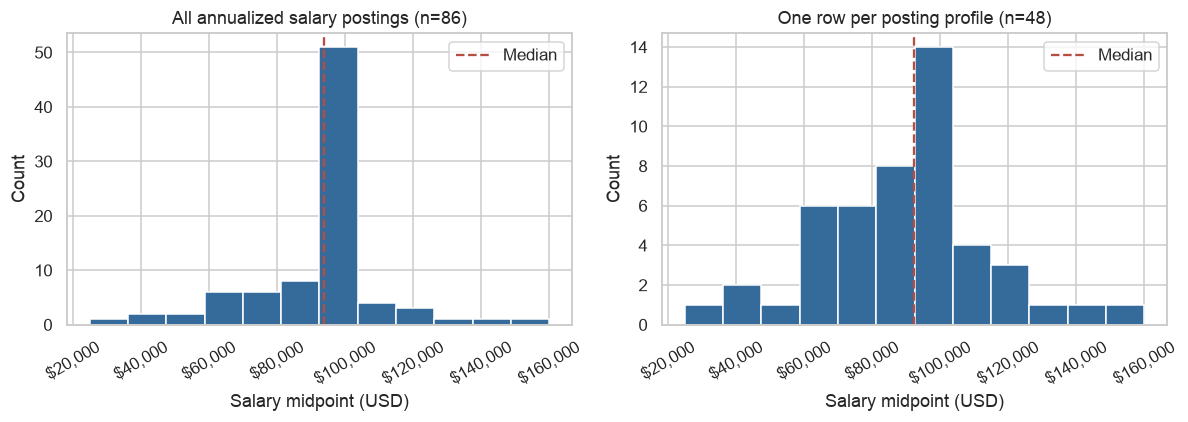

In [8]:
distinct_salary = model_data.drop_duplicates("profile_id")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in [
    (axes[0], model_data, "All annualized salary postings"),
    (axes[1], distinct_salary, "One row per posting profile")
]:
    ax.hist(data["salary_midpoint"], bins=12, color="#346b9a", edgecolor="white")
    ax.axvline(data["salary_midpoint"].median(), color="#b54d42", linestyle="--", label="Median")
    ax.set(title=f"{title} (n={len(data)})", xlabel="Salary midpoint (USD)", ylabel="Count")
    ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "ml_salary_distribution.png", bbox_inches="tight")
plt.show()


## 4. Define predictors and models
Use minimum experience, a missing-experience indicator, eight skill indicators, remote status, city and state.

Exclude salary endpoints and the original salary field because they define or reveal the target. Industry and career scope are fixed by the sample filters and are not useful predictors here.

- **Linear regression:** combines the predictors in a linear equation.
- **Random Forest:** can capture nonlinear relationships; limited tree depth helps control overfitting.
- **Mean baseline:** predicts the same weighted training average for every validation job. It is a comparison benchmark, not the main predictive model.

The pipeline learns missing-value replacements and category encoding from training data only. Each profile receives total weight 1, even when advertised in several cities.


In [9]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

numeric_features = ["MIN_YEARS_EXPERIENCE", "experience_missing"] + list(skill_map)
categorical_features = ["remote_status", "city_clean", "state_clean"]
feature_columns = numeric_features + categorical_features
X = model_data[feature_columns]
y = model_data["salary_midpoint"]
groups = model_data["profile_id"]

# Each distinct profile gets total weight 1, even when posted in many locations.
profile_size = model_data.groupby("profile_id")["ID"].transform("size")
weights = 1 / profile_size
print("Predictors:", feature_columns)
print("Total profile weight:", weights.sum())


Predictors: ['MIN_YEARS_EXPERIENCE', 'experience_missing', 'has_sql', 'has_python', 'has_excel', 'has_bi', 'has_statistics', 'has_visualization', 'has_ml', 'has_aws', 'remote_status', 'city_clean', 'state_clean']
Total profile weight: 48.0


In [10]:
preprocess = ColumnTransformer([
    ("numbers", SimpleImputer(strategy="median"), numeric_features),
    ("categories", OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False), categorical_features)
])

models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Multiple linear regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=4, min_samples_leaf=3, random_state=42, n_jobs=1
    )
}
pipelines = {
    name: Pipeline([("prepare", clone(preprocess)), ("regression", model)])
    for name, model in models.items()
}


## 5. Validate on jobs the models have not seen
Use five grouped validation folds: train on four parts and predict the remaining part, then repeat. The groups are based on posting profiles, not five randomly chosen job categories.

Every profile is held out once. A profile never appears in training and validation in the same round. We do not use a separate final test set; this is an exploratory model comparison.


In [11]:
cv = GroupKFold(n_splits=5)
folds = list(cv.split(X, y, groups))
fold_audit_rows = []
for fold, (train_index, test_index) in enumerate(folds, start=1):
    overlap = set(groups.iloc[train_index]) & set(groups.iloc[test_index])
    assert len(overlap) == 0
    fold_audit_rows.append({
        "Fold": fold, "Training_Rows": len(train_index), "Validation_Rows": len(test_index),
        "Training_Profiles": groups.iloc[train_index].nunique(),
        "Validation_Profiles": groups.iloc[test_index].nunique(),
        "Overlapping_Profiles": len(overlap)
    })
fold_audit = pd.DataFrame(fold_audit_rows)
display(fold_audit)


,Fold,Training_Rows,Validation_Rows,Training_Profiles,Validation_Profiles,Overlapping_Profiles
0,1,48,38,47,1,0
1,2,74,12,37,11,0
2,3,74,12,36,12,0
3,4,74,12,36,12,0
4,5,74,12,36,12,0


In [12]:
cv_predictions = model_data[["ID", "profile_id", "salary_midpoint"]].copy()
fitted_folds = {}

for name, pipeline in pipelines.items():
    predictions = np.zeros(len(model_data))
    fitted_folds[name] = []
    for train_index, test_index in folds:
        model = clone(pipeline)
        model.fit(X.iloc[train_index], y.iloc[train_index],
                  regression__sample_weight=weights.iloc[train_index])
        predictions[test_index] = model.predict(X.iloc[test_index])
        fitted_folds[name].append(model)
    cv_predictions[name] = predictions


## 6. Compare the main results
- **RMSE:** salary error in dollars, giving more weight to large errors. Lower is better.
- **MAE:** average absolute salary error in dollars. Lower is better.
- **R²:** how much the model improves on a mean reference. Higher is better; it is not an accuracy percentage.

Calculate the scores across all held-out predictions, with equal total weight per profile.


In [13]:
metric_rows = []
for name in pipelines:
    prediction = cv_predictions[name]
    metric_rows.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y, prediction, sample_weight=weights)),
        "MAE": mean_absolute_error(y, prediction, sample_weight=weights),
        "R2": r2_score(y, prediction, sample_weight=weights)
    })
metrics = pd.DataFrame(metric_rows).sort_values("RMSE").reset_index(drop=True)
display(metrics.round({"RMSE": 0, "MAE": 0, "R2": 3}))


,Model,RMSE,MAE,R2
0,Random Forest,23781.0,18313.0,0.126
1,Multiple linear regression,25419.0,21622.0,0.002
2,Mean baseline,25572.0,18982.0,-0.010


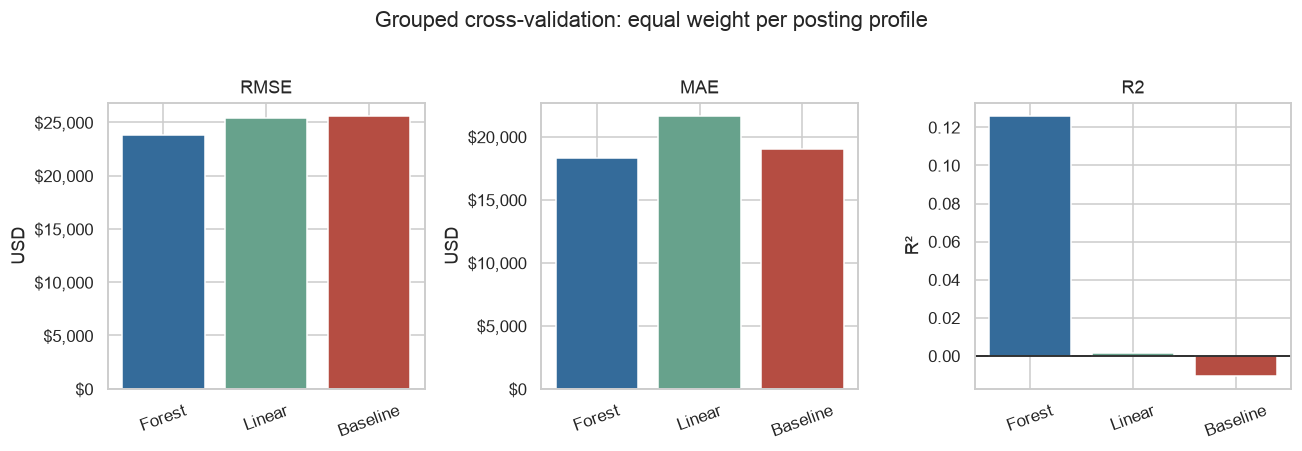

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
short_names = metrics["Model"].replace({"Multiple linear regression": "Linear", "Mean baseline": "Baseline", "Random Forest": "Forest"})
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    ax.bar(short_names, metrics[metric], color=["#346b9a", "#67a28c", "#b54d42"])
    ax.set(title=metric, ylabel="USD" if metric != "R2" else "R²")
    if metric != "R2":
        ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
    else:
        ax.axhline(0, color="black", linewidth=1)
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Grouped cross-validation: equal weight per posting profile", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "ml_model_comparison.png", bbox_inches="tight")
plt.show()


In [15]:
winner = metrics.iloc[0]
baseline_rmse = metrics.loc[metrics["Model"] == "Mean baseline", "RMSE"].iloc[0]
improvement = (baseline_rmse - winner["RMSE"]) / baseline_rmse * 100
conclusion = (
    "The available features do not improve on the simple baseline in this validation."
    if winner["Model"] == "Mean baseline"
    else f"The lowest-RMSE model improves on the baseline by {improvement:.1f}% in this exploratory comparison."
)
display(Markdown(
    f"**Observed result:** {winner['Model']} has the lowest profile-weighted CV RMSE "
    f"(${winner['RMSE']:,.0f}), MAE ${winner['MAE']:,.0f}, and R² {winner['R2']:.3f}. "
    + conclusion + " Scores are uncertain because there are few distinct posting profiles."
))


**Observed result:** Random Forest has the lowest profile-weighted CV RMSE ($23,781), MAE $18,313, and R² 0.126. The lowest-RMSE model improves on the baseline by 7.0% in this exploratory comparison. Scores are uncertain because there are few distinct posting profiles.

### Check the prediction errors
The dashed line shows perfect predictions. Points far from the line show why individual salary estimates need caution. This diagnostic stays inside the notebook and is not exported as another PNG.


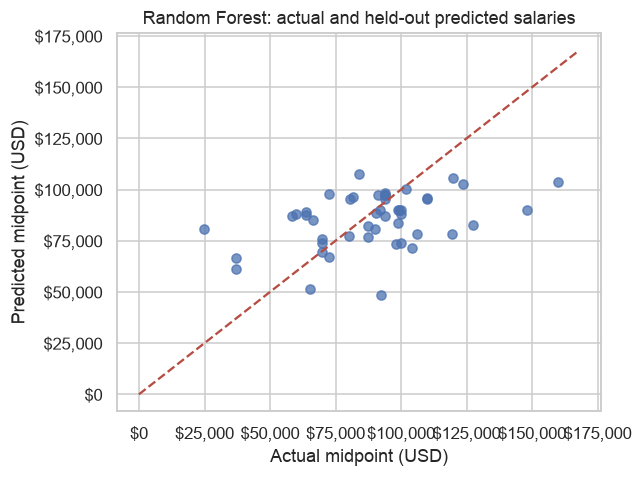

In [16]:
profile_predictions = cv_predictions.groupby("profile_id")[["salary_midpoint", "Random Forest"]].mean()
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(profile_predictions["salary_midpoint"], profile_predictions["Random Forest"], alpha=0.75)
limits = [0, profile_predictions.max().max() * 1.05]
ax.plot(limits, limits, "--", color="#b54d42")
ax.set(title="Random Forest: actual and held-out predicted salaries",
       xlabel="Actual midpoint (USD)", ylabel="Predicted midpoint (USD)")
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
fig.tight_layout()
plt.show()


## 7. Identify the strongest predictive signals
Shuffle one predictor in held-out data and check how much RMSE increases. A larger increase suggests the forest used that predictor. This is a predictive association, not proof of a pay increase from learning a skill.


In [17]:
from sklearn.inspection import permutation_importance

importance_rows = []
for fold, (train_index, test_index) in enumerate(folds):
    model = fitted_folds["Random Forest"][fold]
    importance = permutation_importance(
        model, X.iloc[test_index], y.iloc[test_index],
        scoring="neg_root_mean_squared_error", sample_weight=weights.iloc[test_index],
        n_repeats=5, random_state=42
    )
    for feature, value in zip(feature_columns, importance.importances_mean):
        importance_rows.append({
            "Fold": fold + 1, "Feature": feature, "RMSE_Increase_USD": value,
            "Validation_Profiles": groups.iloc[test_index].nunique()
        })
importance_by_fold = pd.DataFrame(importance_rows)
importance_summary_rows = []
for feature, rows in importance_by_fold.groupby("Feature"):
    importance_summary_rows.append({
        "Feature": feature,
        "RMSE_Increase_USD": np.average(rows["RMSE_Increase_USD"], weights=rows["Validation_Profiles"])
    })
forest_importance = pd.DataFrame(importance_summary_rows).sort_values("RMSE_Increase_USD", ascending=False)


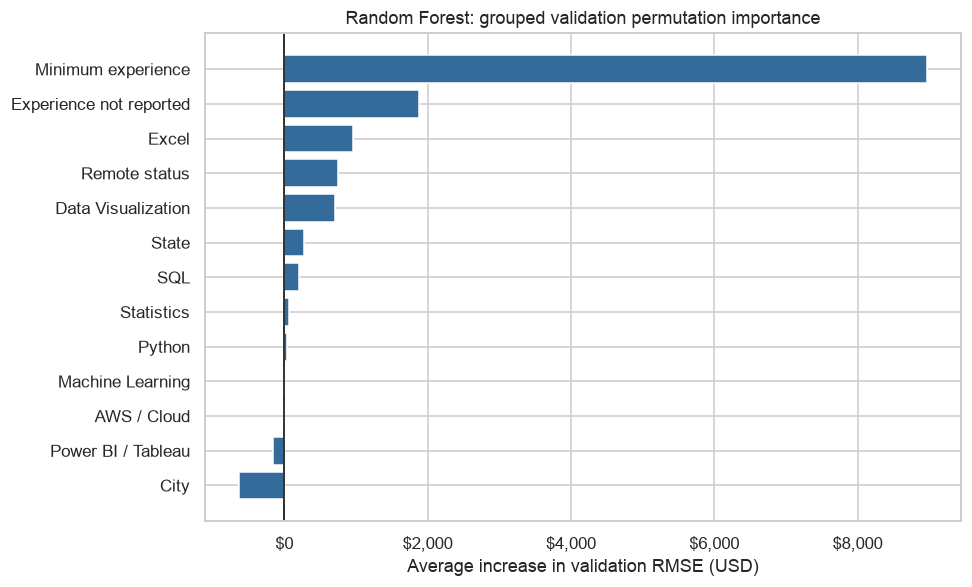

In [18]:
label_map = {**skill_labels, "MIN_YEARS_EXPERIENCE": "Minimum experience",
             "experience_missing": "Experience not reported"}
plot_importance = forest_importance.sort_values("RMSE_Increase_USD")
importance_labels = {**label_map, "remote_status": "Remote status", "city_clean": "City", "state_clean": "State"}
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(plot_importance["Feature"].replace(importance_labels), plot_importance["RMSE_Increase_USD"], color="#346b9a")
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Random Forest: grouped validation permutation importance", xlabel="Average increase in validation RMSE (USD)")
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
fig.tight_layout()
fig.savefig(FIGURES / "ml_forest_importance.png", bbox_inches="tight")
plt.show()


## 8. Limitations and job-seeker interpretation
- **Small salary sample:** 86 postings represent only 48 profiles. The results are uncertain and do not establish national salary expectations.
- **Uneven geographic and employer coverage:** this selected NAICS 523 sample is not representative of every state or employer. Listed cities can also reflect repeated or remote advertising.
- **Historical and incomplete data:** postings cover May–September 2024. Missing salaries, experience and remote status can bias the findings. The low Ariel Investments salary remains a source discrepancy to review.
- **Limited model performance:** the best MAE is about $18,300 and R² is 0.126. Model selection uses the same cross-validation results, with no independent final test.
- **Unmeasured influences:** seniority, education, employer, contract terms and cost of living can affect pay. Skill mentions and predictor importance do not establish causal salary effects.

**Use for a job seeker:** compare similar roles and actual advertised ranges. Use employer skill demand to guide learning; do not treat a predicted midpoint as a personal offer.

Next, collect more recent, independent postings across regions, verify salary values, and evaluate on a new time period or employer sample.


### Keep the recommendation notebook consistent
Save one small JSON file containing the main metrics and sample counts. The recommendation notebook reads this file and checks that the source data has not changed. All detailed tables remain inside the notebooks; no CSV result tables are exported.


In [19]:
import hashlib

summary = {
    "source_sha256": hashlib.sha256(DATA_FILE.read_bytes()).hexdigest(),
    "total_postings": len(df), "all_profiles": int(df["profile_id"].nunique()),
    "model_rows": len(model_data), "model_profiles": int(groups.nunique()),
    "largest_profile_rows": int(profile_counts.iloc[0]),
    "validation": "5-fold grouped validation; equal total weight per profile",
    "metrics": metrics.to_dict("records")
}
(RESULTS / "ml_analysis_summary.json").write_text(json.dumps(summary, indent=2) + "\n")
connection.close()
print("Main results ready for final_recommendations.ipynb")


Main results ready for final_recommendations.ipynb


## Methods and AI use
- Methods: [regression metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics), [pipelines and data leakage](https://scikit-learn.org/stable/common_pitfalls.html), [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html), and [permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html).
- ChatGPT assisted with structure, Python/SQL, validation, figures, interpretation and cleanup. Prompts requested salary-midpoint regression using experience, work arrangement, location and existing skill lists, followed by simpler presentation and explicit limitations. The team should review the results and include the actual prompts required by the instructor.
